In [7]:
import sisl
from Structures.Structures import AuTip_EM, AuTip_EP, AuTip_Dev
from siesta_python.siesta_python import SiP
import numpy as np
import matplotlib.pyplot as plt

g         = sisl.geom.graphene(orthogonal =True)
t1,t2     = 7,10
ndope     = 0.005
basis     = 'SZ'
gd        = g.tile(t1,0).tile(t2,1)
Cg        = gd.center()
Ct        = AuTip_Dev.center()
Rc        = 10.0
split_z   = 4.0

AuTip_Dev = AuTip_Dev.move(Cg-Ct)
AuTip_EP  = AuTip_EP.move(Cg-Ct)
AuTip_EM  = AuTip_EM.move(Cg-Ct)
AuTip_Dev = AuTip_Dev.move([0,0,split_z/2], 
                           atoms=[i for i in range(AuTip_Dev.na) if AuTip_Dev[i,2]>AuTip_Dev.center()[2]])
AuTip_Dev = AuTip_Dev.move([0,0,-split_z/2], 
                           atoms=[i for i in range(AuTip_Dev.na) if AuTip_Dev[i,2]<=AuTip_Dev.center()[2]])
AuTip_EM  = AuTip_EM.move([0,0,-split_z/2])
AuTip_EP  = AuTip_EP.move([0,0,+split_z/2])

gd        = gd.add(AuTip_Dev)
gd        = gd.add_vacuum(AuTip_Dev.cell[2,2]+split_z, 2)
gd        = gd.sub([i for i in range(gd.na) if gd.xyz[i,2]>-0.5])


Directory called ERS already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
Running Siesta electrode calculation in Directory: ERS!



Job completed


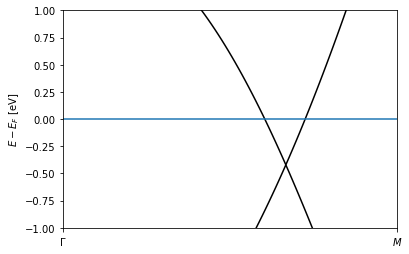

In [8]:
species = 201 * np.ones(len(g.xyz))
Eg      = SiP(g.cell, g.xyz, species, 
              directory_name = 'ERS',
              kp        = [100,100,1], 
              basis     = basis, 
              semi_inf  = 'ab',
              elec_RSSE = True,
              sl = 'ERS', sm = 'ERS',
             )



Eg.fdf(manual_pp = [6,7])
Eg.ps_mixer([ 'C', 'N' ], 1-ndope, 'mix_1')
Eg.dump_pseudo_list_to_struct()
Eg.run_siesta_electrode_in_dir()
He,Se = Eg.to_sisl('fromDFT')
band = sisl.BandStructure(He, [[0, 0, 0], [0, 0.5, 0],
                               ], 100,
                               [r'$\Gamma$', r'$M$',
                               ])
bs = band.apply.array.eigh()

lk, kt, kl = band.lineark(True)
plt.xticks(kt, kl)
plt.xlim(0, lk[-1])
plt.ylim([-1, 1])
plt.ylabel('$E-E_F$ [eV]')
for bk in bs.T:
    plt.plot(lk, bk, color='k')
plt.hlines(0, lk.min(), lk.max())



In [9]:
#EM      = SiP(AuTip_EM.cell, AuTip_EM.xyz, AuTip_EM.atoms.Z, 
#              directory_name = 'EM',
#              kp        = [1,1,41], 
#              basis     = basis, 
#              semi_inf  = '-a3',
#              sl = 'EM', sm = 'EM'
#             )
EP      = SiP(AuTip_EP.cell, AuTip_EP.xyz, AuTip_EP.atoms.Z, 
              directory_name = 'EP',
              kp        = [1,1,41], 
              basis     = basis, 
              semi_inf  = '+a3',
              sl = 'EP', sm = 'EP'
             )
#EM.fdf()
#EM.run_siesta_electrode_in_dir()
#EP.fdf()
#EP.run_siesta_electrode_in_dir()





Directory called EP already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!


In [10]:
Dev = SiP(gd.cell, gd.xyz, gd.atoms.Z,
          solution_method = 'transiesta',
          directory_name = 'Device',
          kp = [1,1,1],
          elecs = [EP,Eg],
          Chem_Pot= [.0, .0, .0],
          basis = basis,
          save_SE  = True
         )



Directory called Device already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!


/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:350: EdgeCaseWarning: aP lattice, but the k_alpha3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:355: EdgeCaseWarning: aP lattice, but the k_beta3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:360: EdgeCaseWarning: aP lattice, but the k_gamma3 angle is almost equal to 90 degrees
  warnings.warn(


In [11]:
Dev.pickle('Device')

In [6]:
Dev.ase_visualise()

In [ ]:
from ase.visualize import view

In [ ]:
view(AuTip_Dev.toASE())

In [ ]:
EM.pos_real_space